<a href="https://colab.research.google.com/github/ny862571-hash/Plant-Disease-Classification/blob/main/Plant_Diseases_classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import os

# This will ask you to select the 'kaggle.json' from your Downloads
files.upload()

# This moves the file to the correct hidden folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle is now connected to Colab!")

Saving kaggle.json to kaggle.json
Kaggle is now connected to Colab!


In [ ]:
# 1. Download the dataset using the ID from the Kaggle URL
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

# 2. Unzip the file
import zipfile
import os

# The file downloaded will be named [dataset-name].zip
zip_path = 'plantvillage-dataset.zip'
extract_path = '/content/plant_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully to /content/plant_data!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:20<00:00, 108MB/s]

Dataset extracted successfully to /content/plant_data!


In [ ]:
import os
# This lists the main folders inside your extracted path
print(os.listdir('/content/plant_data'))

# If you see a folder called 'plantvillage dataset', look inside it
# Adjust this path based on the output of the line above
path = '/content/plant_data/plantvillage dataset/color'
if os.path.exists(path):
    print("Categories found:", os.listdir(path))

['plantvillage dataset']
Categories found: ['Corn_(maize)___Northern_Leaf_Blight', 'Peach___healthy', 'Tomato___Late_blight', 'Tomato___Early_blight', 'Tomato___Leaf_Mold', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___healthy', 'Pepper,_bell___Bacterial_spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Septoria_leaf_spot', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Pepper,_bell___healthy', 'Tomato___Target_Spot', 'Grape___Black_rot', 'Potato___Early_blight', 'Raspberry___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Blueberry___healthy', 'Apple___Apple_scab', 'Corn_(maize)___healthy', 'Potato___Late_blight', 'Orange___Haunglongbing_(Citrus_greening)', 'Apple___healthy', 'Soybean___healthy', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Peach___Bacterial_spot', 'Grape___Esca_(Black_Measles)', 'Apple___Cedar_apple_rust', 'Corn_(maize)___Common_rust_', 'Squash___Powdery_mildew', 'Cherry_(inc

In [ ]:
import tensorflow as tf

# Set your data path based on what you found in Step 1
DATA_PATH = '/content/plant_data/plantvillage dataset/color'

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [ ]:
from tensorflow.keras import layers, models

# 1. Define the Input explicitly (solves the AttributeErrors)
inputs = tf.keras.Input(shape=(256, 256, 3), name="leaf_input_layer")

# 2. Rescale pixel values
x = layers.Rescaling(1./255)(inputs)

# 3. First Convolutional block
x = layers.Conv2D(32, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 4. Second Convolutional block
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 5. Third Convolutional block (This is our Grad-CAM target)
# We name it specifically so the code can always find it easily
x = layers.Conv2D(64, (3, 3), activation='relu', name="final_conv_layer")(x)
x = layers.MaxPooling2D((2, 2))(x)

# 6. Flatten and Classify
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(38, activation='softmax')(x)

# 7. Create the Model
model = models.Model(inputs=inputs, outputs=outputs)

# 8. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ leaf_input_layer (InputLayer)   │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_conv_layer (Conv2D)       │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,745,254 (14.29 MB)

 Trainable params: 3,745,254 (14.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# This will take some time. Watch the 'accuracy' go up!
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 70ms/step - accuracy: 0.6900 - loss: 1.1007 - val_accuracy: 0.8135 - val_loss: 0.6138
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 90s 66ms/step - accuracy: 0.8786 - loss: 0.3923 - val_accuracy: 0.8879 - val_loss: 0.3770
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 89s 65ms/step - accuracy: 0.9257 - loss: 0.2337 - val_accuracy: 0.8986 - val_loss: 0.3529
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 89s 65ms/step - accuracy: 0.9536 - loss: 0.1420 - val_accuracy: 0.8784 - val_loss: 0.4660
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 88s 65ms/step - accuracy: 0.9624 - loss: 0.1133 - val_accuracy: 0.8879 - val_loss: 0.4315
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 88s 65ms/step - accuracy: 0.9727 - loss: 0.0871 - val_accuracy: 0.8696 - val_loss: 0.5151
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 88s 65ms/step - accuracy: 0.9766 - loss: 0.0725 - val_accuracy: 0.8958 - val_loss: 0.4717
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 92s 67ms/step - accuracy: 0.9792 

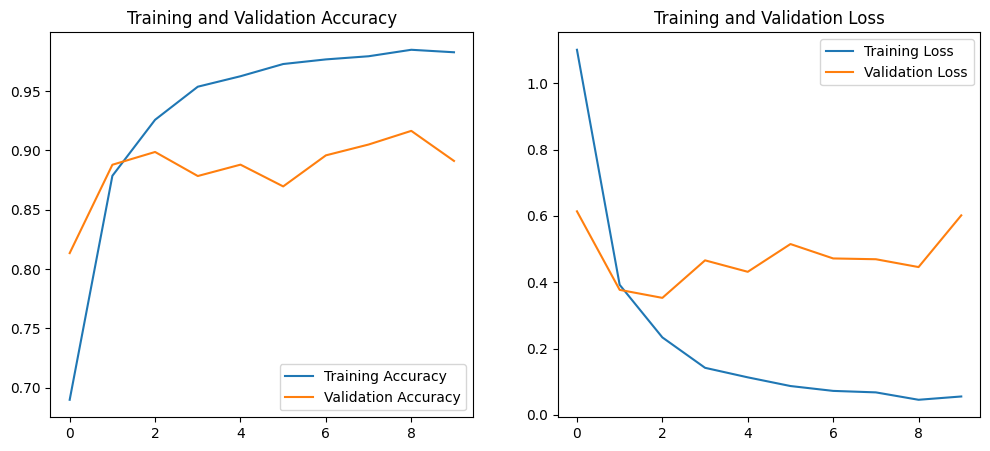

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss') # Changed from elapsed_range
plt.plot(epochs_range, val_loss, label='Validation Loss') # Changed from elapsed_range
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()

In [ ]:
import os
import shutil

# 1. Create the 'test' folder and a subfolder for the images
# (We put them in 'unknown' because we'll let the AI tell us what they are)
os.makedirs('test/images', exist_ok=True)

# 2. Move all uploaded JPG files into that folder
for file in os.listdir():
    if file.endswith('.JPG') or file.endswith('.jpg'):
        shutil.move(file, os.path.join('test/images', file))

print("✅ Folder structure fixed! Your images are now in 'test/images'")

✅ Folder structure fixed! Your images are now in 'test/images'


In [ ]:
class_names = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy',
    'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot',
    'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy',
    'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch',
    'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight',
    'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy'
]

In [ ]:
# Create the predictions variable before using it
predictions = model.predict(val_ds)

340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step


In [ ]:
import numpy as np

# 1. Define class names (if not already defined)
class_names = [...] # Your full list of 38 classes

# 2. GENERATE THE PREDICTIONS (This fixes your error!)
predictions = model.predict(val_ds)

# 3. Show the Results with the FULL list
for i in range(len(predictions)):
    result_index = np.argmax(predictions[i])
    # Safety check to make sure the index exists in our list
    if result_index < len(class_names):
        print(f"Image {i+1}: AI predicts -> {class_names[result_index]}")
    else:
        print(f"Image {i+1}: Prediction index {result_index} is outside our current list!")

Streaming output truncated to the last 5000 lines.
Image 5862: Prediction index 35 is outside our current list!
Image 5863: Prediction index 28 is outside our current list!
Image 5864: Prediction index 12 is outside our current list!
Image 5865: Prediction index 25 is outside our current list!
Image 5866: Prediction index 15 is outside our current list!
Image 5867: Prediction index 35 is outside our current list!
Image 5868: Prediction index 16 is outside our current list!
Image 5869: Prediction index 15 is outside our current list!
Image 5870: Prediction index 8 is outside our current list!
Image 5871: Prediction index 16 is outside our current list!
Image 5872: Prediction index 24 is outside our current list!
Image 5873: Prediction index 37 is outside our current list!
Image 5874: Prediction index 12 is outside our current list!
Image 5875: Prediction index 15 is outside our current list!
Image 5876: Prediction index 24 is outside our current list!
Image 5877: Prediction index 15 is 

In [ ]:
def predict_leaf(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(256, 256))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    # This line was crashing because the list was too short
    print(f"Prediction: {class_names[predicted_class_idx]}")
    print(f"Confidence: {100 * confidence:.2f}%")

Predicting validation set... this may take a minute.


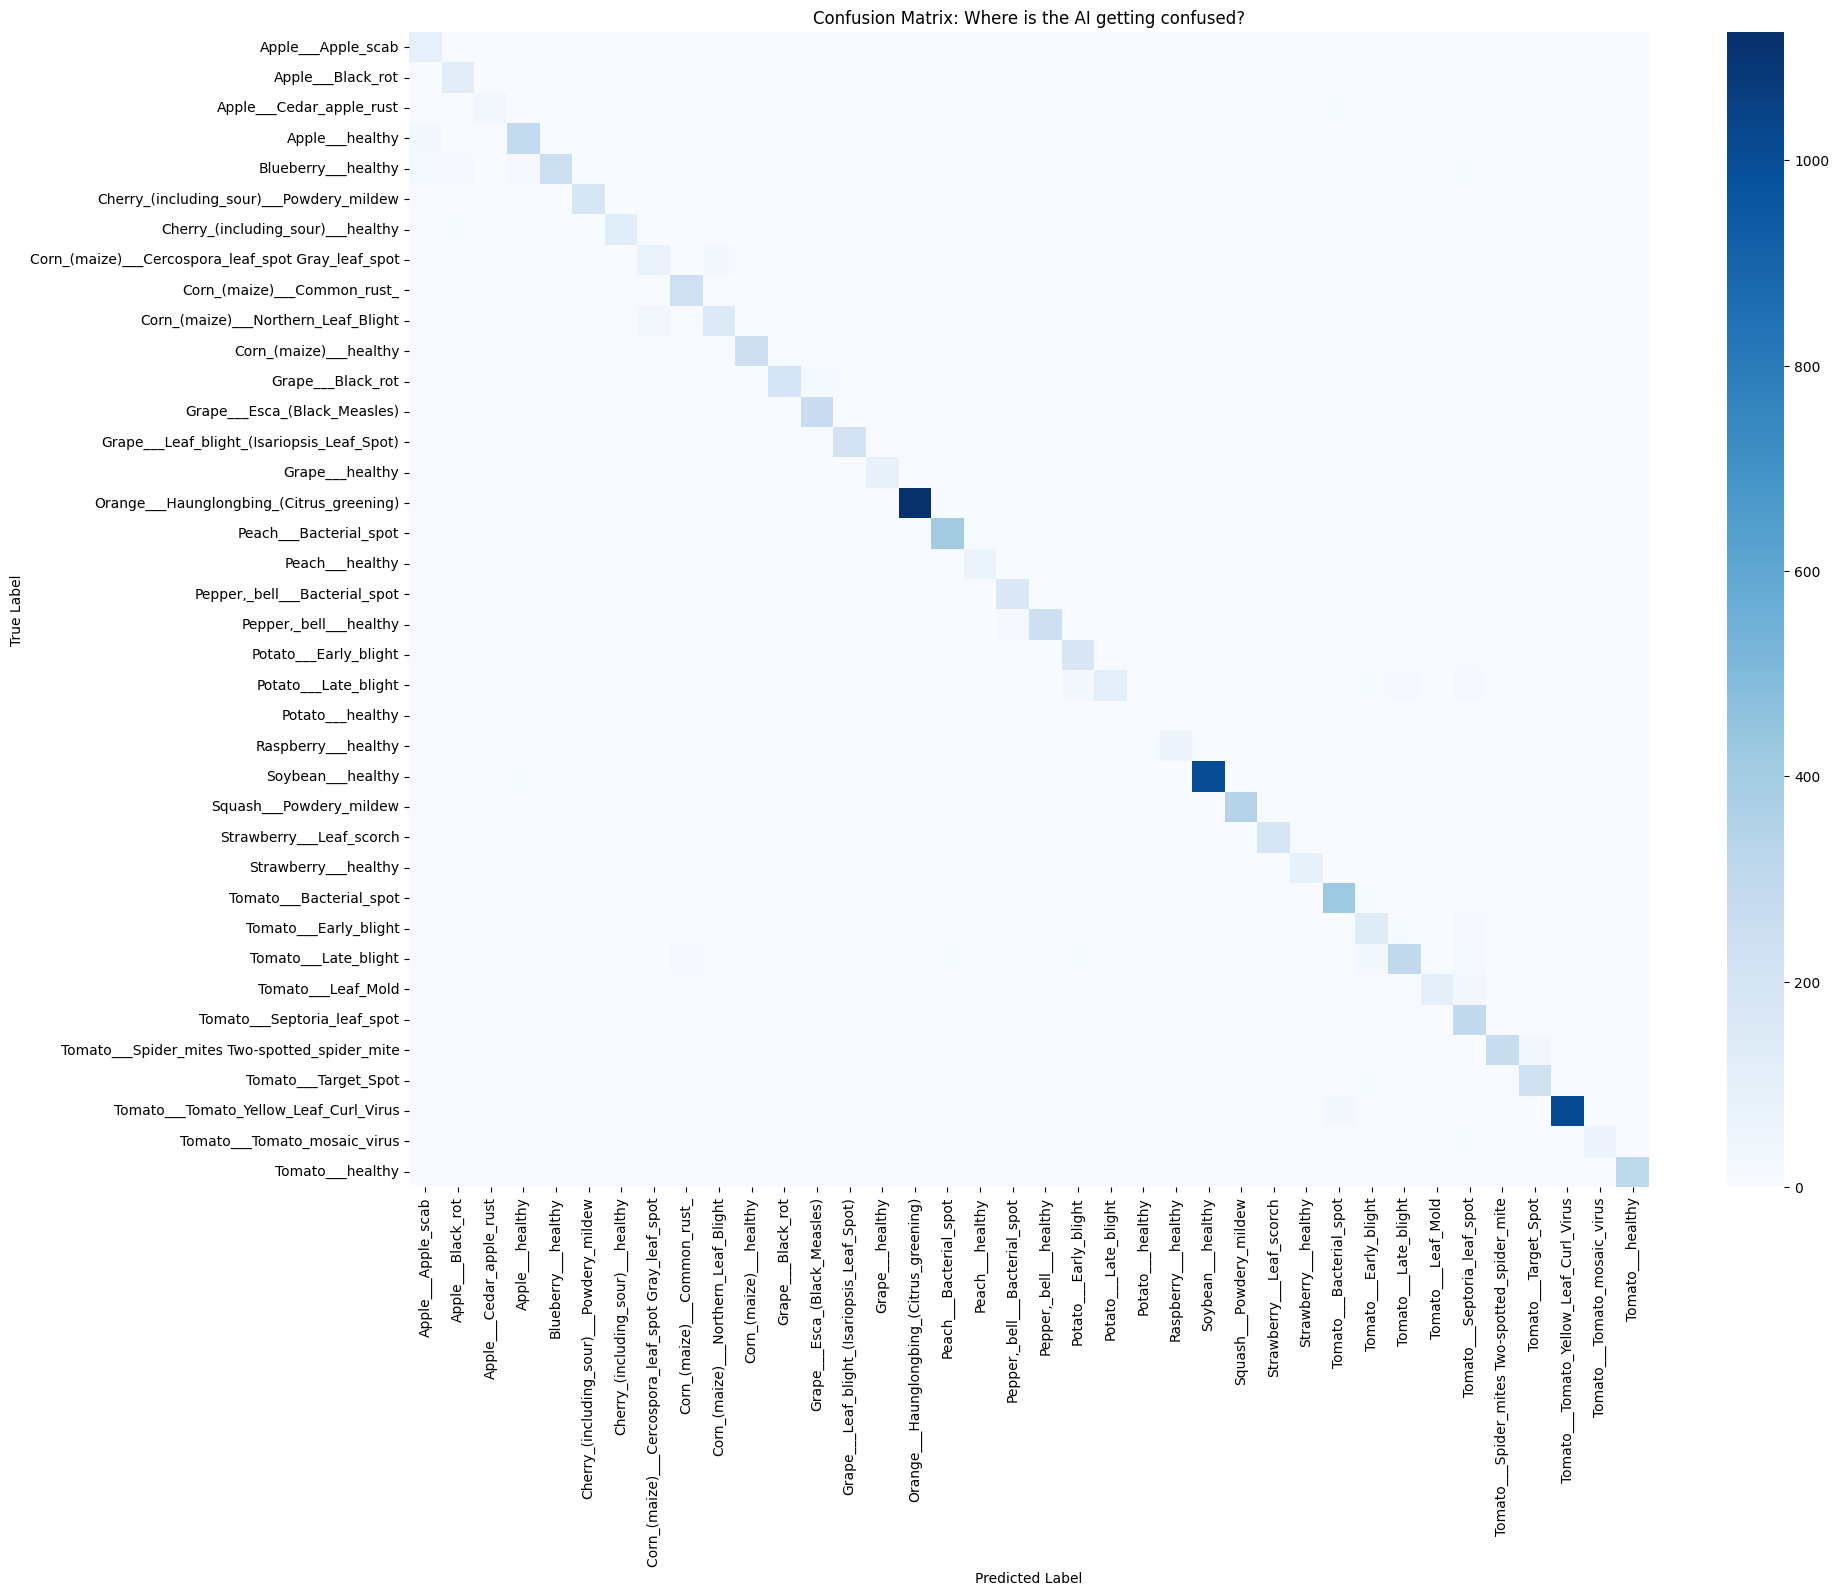

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Generate predictions for the validation set
# This fixes the "name 'predictions' is not defined" error
print("Predicting validation set... this may take a minute.")
y_true = []
y_pred = []

for images, labels in val_ds:
    # Get AI predictions
    preds = model.predict(images, verbose=0)

    # Store real labels and predicted labels
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Compute the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot the Heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    fmt='g',
    xticklabels=class_names, # Ensure class_names is defined in the cell above
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Where is the AI getting confused?')
plt.show()

In [ ]:
# Save the model so you can use it later without re-training
model.save('plant_disease_model.h5')
print("Success! Your model is saved as 'plant_disease_model.h5'")

Success! Your model is saved as 'plant_disease_model.h5'


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

def predict_leaf(img_path):
    # 1. Load the image with the exact same size used in training
    img = image.load_img(img_path, target_size=(256, 256))

    # 2. Convert to array
    img_array = image.img_to_array(img)

    # 3. Add batch dimension
    img_array = tf.expand_dims(img_array, 0)

    # 4. Make prediction
    # Since your model ALREADY has a softmax layer at the end,
    # do NOT apply tf.nn.softmax again here.
    predictions = model.predict(img_array)

    # 5. Get the highest score and its index
    predicted_class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) # Get value directly from model output

    print(f"Prediction: {class_names[predicted_class_idx]}")
    print(f"Confidence: {100 * confidence:.2f}%")

In [ ]:
# Upload an image from your PC
uploaded = files.upload()

for filename in uploaded.keys():
    predict_leaf(filename)

Saving potato dis.JPG to potato dis (1).JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction: Potato___Late_blight
Confidence: 99.95%
